# **Importing Libraries**

In [53]:
# Analysis 
import numpy as np
import pandas as pd
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Rendering plotly figures
import plotly.io as pio
pio.renderers.default = "svg"

# Preprocessing 
from sklearn.preprocessing import LabelEncoder , PowerTransformer
from sklearn.model_selection import train_test_split , StratifiedKFold , RandomizedSearchCV , cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Classification Models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier 

# Evaluation 
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix , roc_auc_score , roc_curve

# Saving Models
import joblib as jl

In [54]:
import warnings
warnings.filterwarnings("ignore")

# **Laoding The Dataset**

In [55]:
df = pd.read_csv("loan_approval_dataset.csv", sep= ',')
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# **Data cleaning**

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [58]:
df.describe(exclude=np.number).T

,count,unique,top,freq
education,4269,2,Graduate,2144
self_employed,4269,2,Yes,2150
loan_status,4269,2,Approved,2656


In [59]:
df.duplicated().sum()

0

In [60]:
df.isna().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

# **EDA**

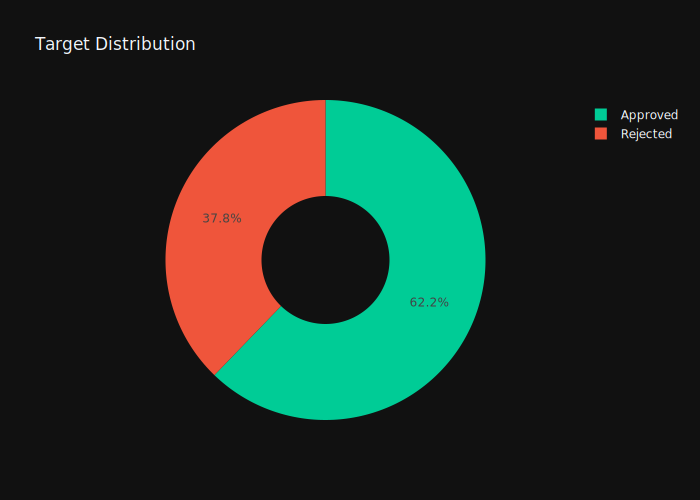

In [61]:
fig1 = px.pie(df,
              names=" loan_status",
              hole=0.4,
              title="Target Distribution",
              color_discrete_sequence=['#00CC96','#EF553B'],
              template="plotly_dark")

fig1.show()

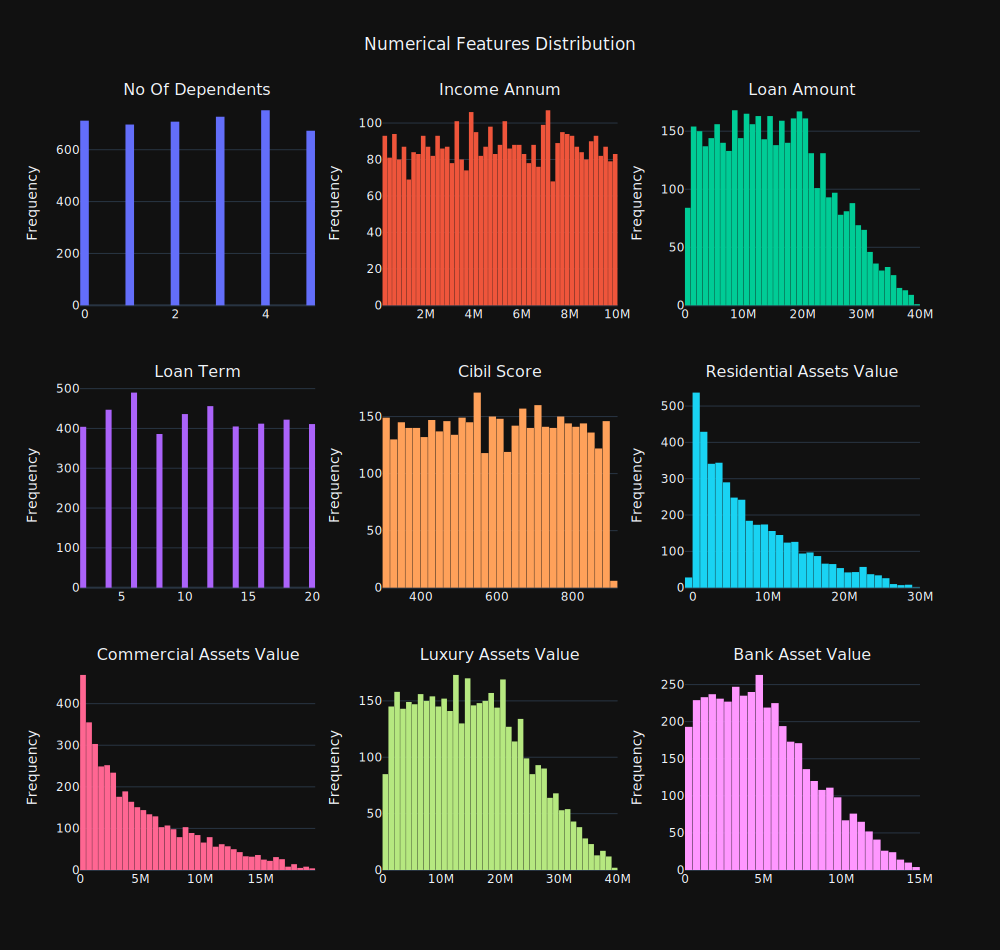

In [62]:
num_cols = [' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']
colors = colors = px.colors.qualitative.Plotly

fig2 = make_subplots(rows= 3, 
                     cols= 3, 
                     subplot_titles= [j.replace("_", " ").title() for j in num_cols],
                     horizontal_spacing=0.08,
                     vertical_spacing=0.10)

rows, cols = 1 , 1

for i , col in enumerate(num_cols):

    color = colors[i % len(colors)]

    fig2.add_trace(
        go.Histogram(
        x=df[col],
        nbinsx=50,
        marker_color= color,
        name= col.replace("_", " ")
    ),
    row=rows,
    col=cols)

    fig2.update_yaxes(
        title_text="Frequency",
        row=rows,
        col=cols
    ) 

    cols += 1
    if cols > 3 :
        rows +=1 
        cols = 1   


fig2.update_layout(
    title="Numerical Features Distribution",
    title_x=0.5,
    template="plotly_dark",
    height=950,
    width=1000,
    bargap=0.05,
    showlegend=False
)

fig2.show()


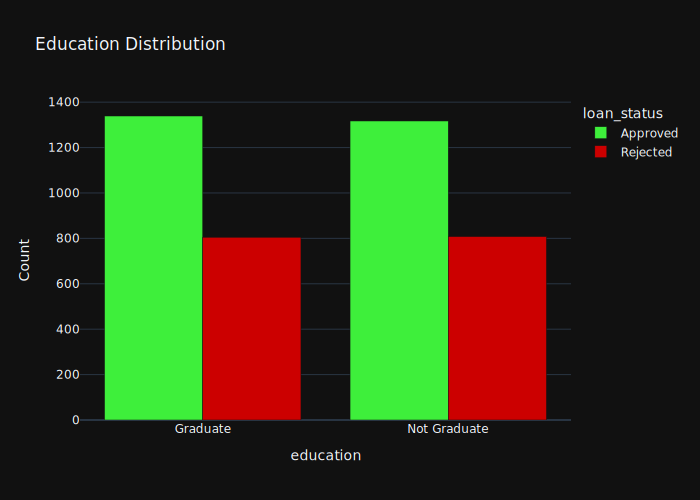

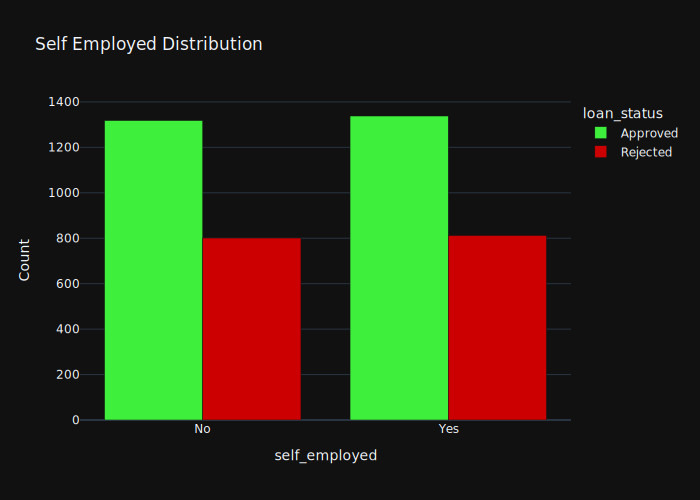

In [63]:
cat_cols = [' education', ' self_employed']

for col in cat_cols:
    df1 = df.groupby([col, ' loan_status']).size().reset_index(name='Count')

    fig3 = px.bar(
        df1,
        x= col,
        y= 'Count',
        color= ' loan_status',
        title= f"{col.replace('_', ' ').title()} Distribution",
        color_discrete_sequence=['#3EEF3B', '#CC0000'],
        barmode= 'group',
        template= "plotly_dark"
    )
    
    fig3.show()

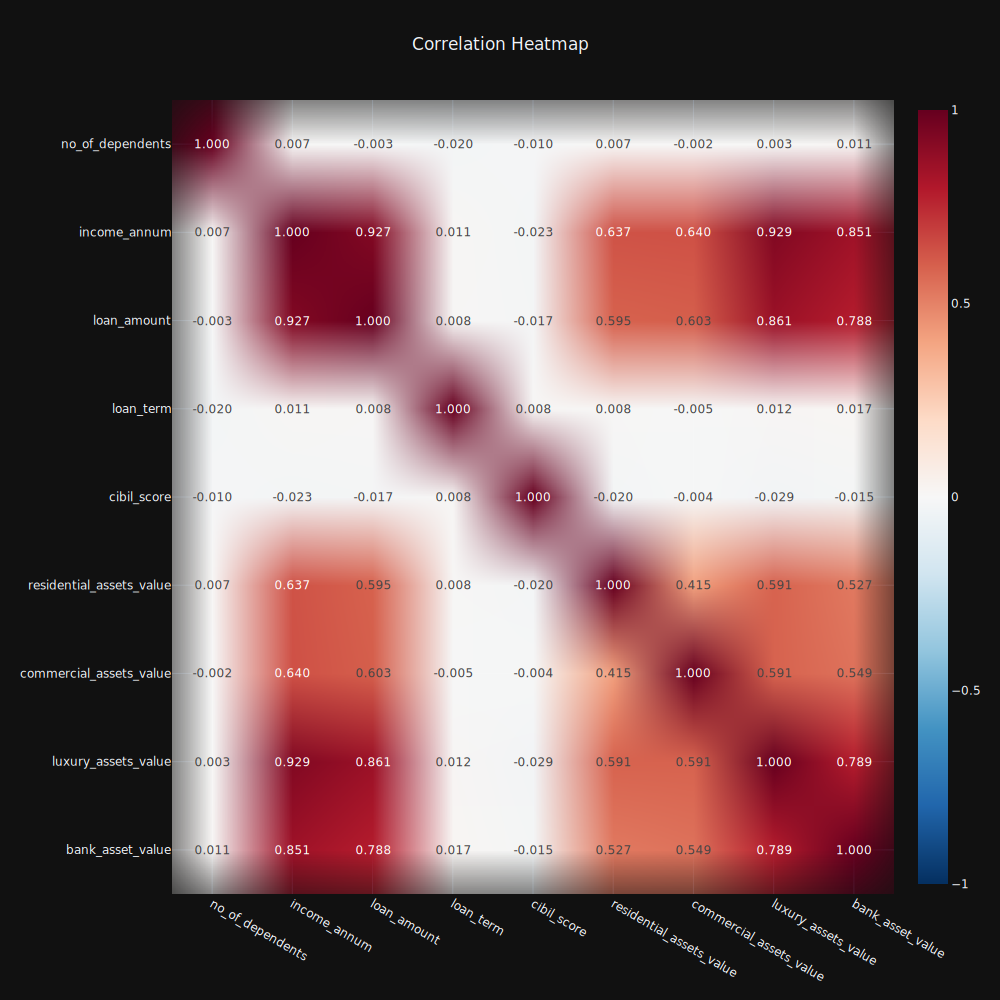

In [80]:
corr = df[num_cols].corr()

fig4 = px.imshow(corr,
                 zmax= 1,
                 zmin=-1,
                 title= "Correlation Heatmap",
                 text_auto= '.3f',
                 aspect= 'auto',
                 color_continuous_scale='RdBu_r',
                 template='plotly_dark').update_layout(title_x= 0.5,
                                                       height=1000,
                                                       width=1000)

fig4.show()

# **Data Preprocessing**

**1. Feature Encoding**

In [65]:
df2= df.copy()
le = LabelEncoder()

for col in df.select_dtypes(exclude=np.number).columns.tolist():
    df2[col] = le.fit_transform(df[col])    

**2. Feature Scaling**

In [66]:
num_f = Pipeline(steps=[
    ('num', PowerTransformer(method= 'yeo-johnson'))
])

scaler = ColumnTransformer(transformers=[
    ('skewness', num_f, num_cols)
])

# **Train & Test Split**

In [67]:
X = df2.drop(columns=['loan_id', ' loan_status'])
y = df2[' loan_status']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size= 0.2,
                                                    stratify= y,
                                                    random_state= 42)

# **Training Models**

In [69]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest" : RandomForestClassifier(max_depth=5, random_state=42),
    "XGBoost" : XGBClassifier(n_estimators= 130, random_state=42, max_depth=5)
}

for name, model in models.items():
    print(f"Training {name}...")

    full_pip = Pipeline(steps=[
        ('scaler' , scaler),
        (name, model)
    ])

    cv = cross_validate(full_pip, 
                        X_train, 
                        y_train, 
                        cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
                        scoring=["f1", "precision", "recall", "accuracy"],
                        n_jobs=-1)
    
    print(f"F1-Score:    {np.mean(cv['test_f1']):.3f}")
    print(f"Precision:   {np.mean(cv['test_precision']):.3f}")
    print(f"Recall:      {np.mean(cv['test_recall']):.3f}")
    print(f"Accuracy:    {np.mean(cv['test_accuracy']):.3f}\n")

Training Logistic Regression...
F1-Score:    0.881
Precision:   0.889
Recall:      0.874
Accuracy:    0.911

Training Random Forest...
F1-Score:    0.958
Precision:   0.946
Recall:      0.971
Accuracy:    0.968

Training XGBoost...
F1-Score:    0.980
Precision:   0.988
Recall:      0.974
Accuracy:    0.985



# **Fine-Tuning**

In [70]:
param_grids = {
    "Logistic Regression" : {
              "Logistic Regression__penalty": ["l1", "l2", "elasticnet"], 
              "Logistic Regression__C": [100, 10, 1, 0.1, 0.01], 
              "Logistic Regression__solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga", "newton-cholesky"]
    },

    
    "Random Forest" : {
        "Random Forest__max_depth": [5, 8, 15, 20, 10], 
        "Random Forest__max_features": ["sqrt", "log2"], 
        "Random Forest__min_samples_split": [2, 8, 15], 
        "Random Forest__n_estimators": [100, 150 ,200, 500, 1000]
    },
    
    "XGBoost" : {
        "XGBoost__n_estimators": [100, 150, 200, 500, 1000], 
        "XGBoost__learning_rate": [0.001, 0.01, 0.1, 1, 10],
        "XGBoost__max_depth": [5, 8, 15, 20, 10]
    }
}

best_models = {}
best_scores = []

for name, model in models.items():
    print(f"Fine-Tuning {name}...")

    full_pip = Pipeline(steps=[
        ('scaler', scaler),
        (name, model)
    ])

    rs = RandomizedSearchCV(estimator= full_pip,
                            param_distributions= param_grids[name],
                            n_iter=10,
                            n_jobs= -1,
                            scoring= ["f1", "precision", "recall", "accuracy"],
                            refit="f1",
                            cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            random_state= 42)
    
    rs.fit(X_train, y_train)

    results = pd.DataFrame(rs.cv_results_)
    best = results.loc[rs.best_index_]

    print(f"F1 Score:     {best['mean_test_f1']:.3f}")
    print(f"Precision:    {best['mean_test_precision']:.3f}")
    print(f"Recall:       {best['mean_test_recall']:.3f}")
    print(f"Accuracy :    {best['mean_test_accuracy']:.3f}")
    print(f"Best {name} Parameters:   {rs.best_params_}\n")
    print("-" * 180, "\n")

    best_models[name] = rs.best_estimator_
    best_scores.append({
        "Model" : name,
        "CV_Accuracy" : best['mean_test_accuracy']
    }) 

Fine-Tuning Logistic Regression...
F1 Score:     0.883
Precision:    0.894
Recall:       0.871
Accuracy :    0.912
Best Logistic Regression Parameters:   {'Logistic Regression__solver': 'newton-cholesky', 'Logistic Regression__penalty': 'l2', 'Logistic Regression__C': 0.1}

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ 

Fine-Tuning Random Forest...
F1 Score:     0.979
Precision:    0.985
Recall:       0.973
Accuracy :    0.984
Best Random Forest Parameters:   {'Random Forest__n_estimators': 1000, 'Random Forest__min_samples_split': 2, 'Random Forest__max_features': 'sqrt', 'Random Forest__max_depth': 15}

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ 

Fine-Tuning XGBoost...
F1 Score:     0.983
Precision:    0.988
Recal

# **Stacking Classifier**

In [71]:
stack = StackingClassifier(
    estimators= list(best_models.items()),
    final_estimator= LogisticRegression(),
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

stack.fit(X_train, y_train)

cv2 = cross_validate(stack, 
                        X_train, 
                        y_train, 
                        cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
                        scoring=["f1", "precision", "recall", "accuracy"],
                        n_jobs=-1)

print(f"Stack F1-Score:    {np.mean(cv2['test_f1']):.3f}")
print(f"Stack Precision:   {np.mean(cv2['test_precision']):.3f}")
print(f"Stack recall:      {np.mean(cv2['test_recall']):.3f}")
print(f"Stack Accuracy:    {np.mean(cv2['test_accuracy']):.3f}")

Stack F1-Score:    0.983
Stack Precision:   0.987
Stack recall:      0.979
Stack Accuracy:    0.987


# **Model Comparison**

In [72]:
for i , (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    best_scores[i]["Test_Accuracy"] = accuracy_score(y_test, y_pred)

y_pred_s = stack.predict(X_test)
best_scores.append({
    "Model" : "Stacking Classifier",
    "CV_Accuracy" : 0.987,
    "Test_Accuracy" : accuracy_score(y_test, y_pred_s)
})    

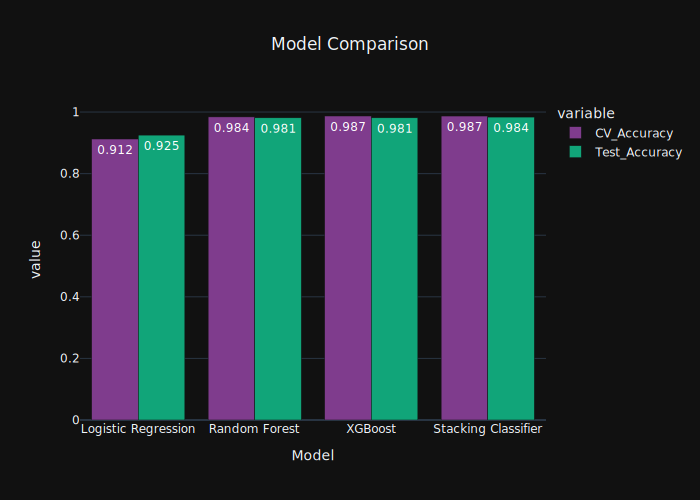

In [73]:
comp = pd.DataFrame(best_scores)
fig5 = px.bar(comp,
              x= "Model", 
              y= ["CV_Accuracy", "Test_Accuracy"],
              title="Model Comparison",
              barmode='group',
              color_discrete_sequence=px.colors.qualitative.Bold,
              text_auto= '.3f',
              template='plotly_dark').update_layout(title_x= 0.5)

fig5.show()

# **Model Evaluation**

**1. Classification Report**

In [74]:
print(f"Stack Classification Report: \n {classification_report(y_test, y_pred_s)}\n")

Stack Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.98      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854




**2. Confusion Matrix**

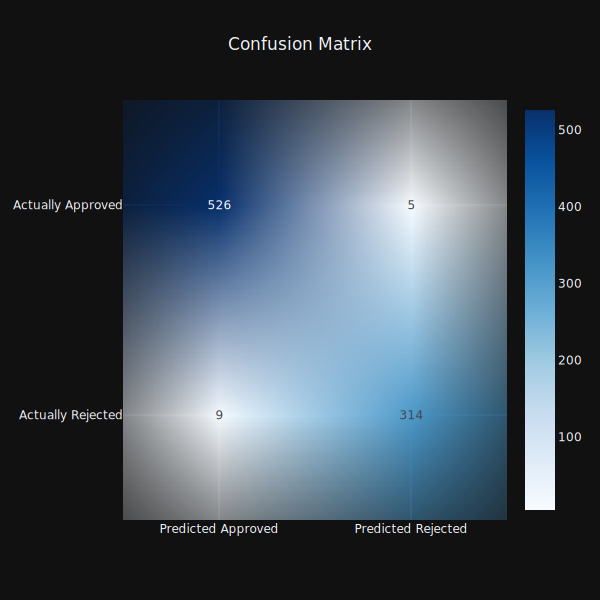

In [75]:
cm = confusion_matrix(y_test, y_pred_s)
fig6 = px.imshow(cm,
                 zmax=cm.max(),
                 zmin=cm.min(),
                 title= "Confusion Matrix",
                 x=["Predicted Approved", "Predicted Rejected"],
                 y=["Actually Approved", "Actually Rejected"],
                 color_continuous_scale="Blues",
                 text_auto= True,
                 aspect='auto',
                 template='plotly_dark').update_layout(title_x=0.5,
                                                       height=600,
                                                       width=600)

fig6.show()

**3. ROC-AUC Curve**

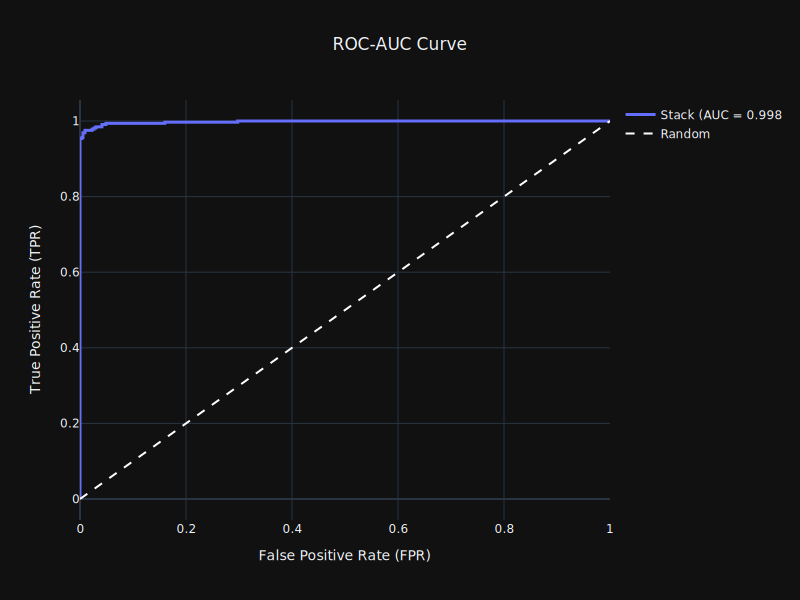

In [76]:
fig7 = go.Figure()

y_prob = stack.predict_proba(X_test)[:,1]

fpr, tpr , threshold = roc_curve(y_test, y_prob)

fig7.add_trace(
    go.Scatter(
        x=fpr,
        y=tpr,
        mode='lines',
        name= f"Stack (AUC = {roc_auc_score(y_test, y_prob):.3f}",
        line=dict(width=3)
    )
)

fig7.add_trace(
    go.Scatter(
        x=[0,1],
        y=[0,1],
        mode='lines',
        name= "Random",
        line=dict(color='white', dash='dash', width=2)
    )
)

fig7.update_layout(
    title="ROC-AUC Curve",
    title_x=0.5,
    xaxis_title="False Positive Rate (FPR)",
    yaxis_title="True Positive Rate (TPR)",
    template="plotly_dark",
    width=800,
    height=600
)

fig7.show()

**4. Feature Importance**

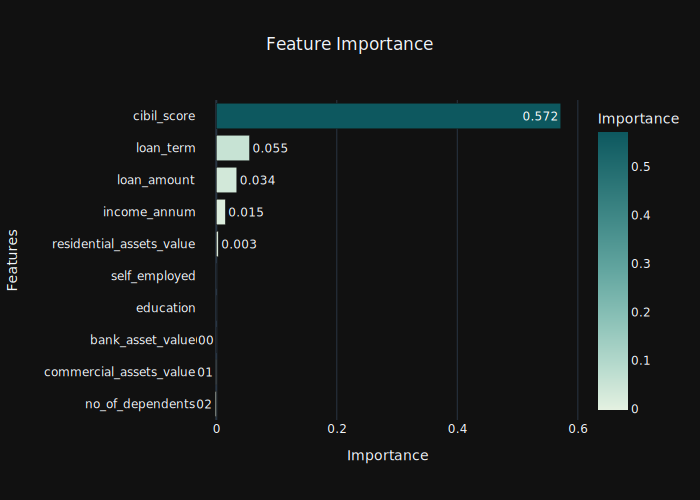

In [77]:
f_imp = permutation_importance(
    stack, X_test, y_test, random_state=42, n_jobs=-1, n_repeats=5, scoring='f1'
)

f_imp_df = pd.DataFrame({
    "Features" : X_test.columns,
    "Importance" : f_imp.importances_mean
}).sort_values(by="Importance", ascending=True).tail(10)

fig8 = px.bar(
    f_imp_df,
    x="Importance",
    y="Features",
    color="Importance",
    text_auto=".3f",
    orientation="h",
    title="Feature Importance",
    color_continuous_scale="mint"
).update_layout(
    title_x= 0.5,
    template="plotly_dark"
)

fig8.show()

# **Saving Model**

In [78]:
jl.dump(stack, "stack.pkl")

['stack.pkl']